**BÀI TẬP MẪU**

In [ ]:
# Import các thư viện cần thiết
!pip install scikeras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, OneHotEncoder

In [ ]:
# 7.Tải bộ mnist fashion datasets
from re import X
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler
# 3D to 2D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
#Feature scaling
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))

Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


<function matplotlib.pyplot.show(close=None, block=None)>

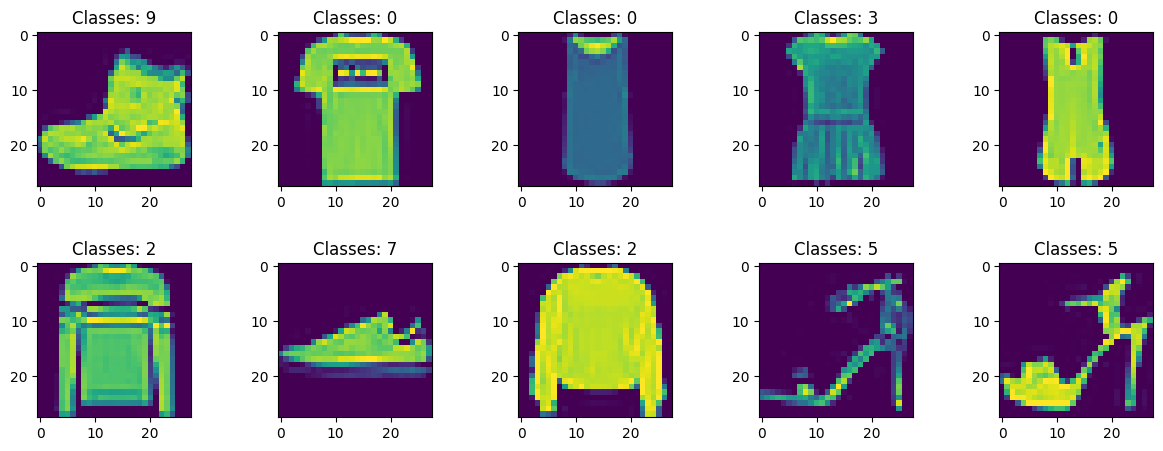

In [ ]:
#Truc quan hoa du lieu
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Classes: '+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show

In [ ]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7753 - loss: 0.6529 - val_accuracy: 0.8452 - val_loss: 0.4169
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8629 - loss: 0.3774 - val_accuracy: 0.8698 - val_loss: 0.3610
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8776 - loss: 0.3351 - val_accuracy: 0.8707 - val_loss: 0.3593
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8878 - loss: 0.3026 - val_accuracy: 0.8798 - val_loss: 0.3401
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8940 - loss: 0.2838 - val_accuracy: 0.8827 - val_loss: 0.3257
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9003 - loss: 0.2690 - val_accuracy: 0.8820 - val_loss: 0.3291
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9042 - loss: 0.2537 - val_accuracy: 0.8845 - val_loss: 0.3229
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9101 - loss: 0.

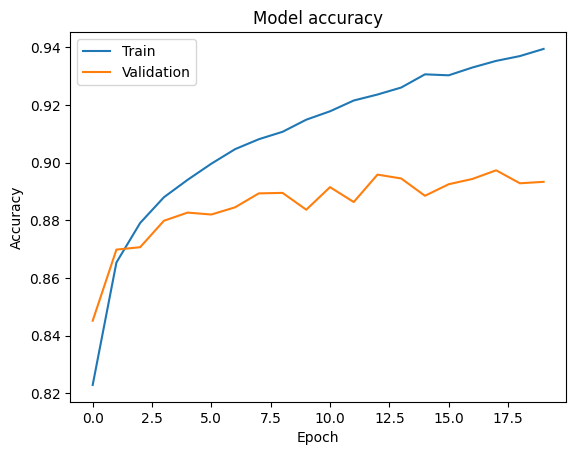

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

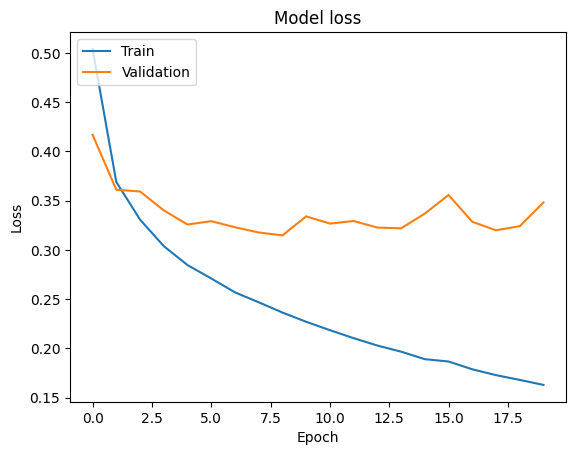

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [ ]:
import pandas as pd
mnist_train_path = '/content/fashion-mnist_test.csv'
mnist_test_path = '/content/fashion-mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...     103.0      87.0      56.0       0.0       0.0       0.0   
1       0  ...      34.0       0.0       0.0       0.0       0.0       0.0   
2      99  ...       0.0       0.0       0.0       0.0      63.0      53.0   
3       0  ...     137.0     126.0     140.0       0.0     133.0     224.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  pixel784  
0       0.0       0.0       0.

In [ ]:
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print(X_train.shape)

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of Classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))

(1886, 784)
Number of Classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4422 - loss: 27.8673 - val_accuracy: 0.6455 - val_loss: nan
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7077 - loss: 2.7268 - val_accuracy: 0.6878 - val_loss: nan
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7651 - loss: 0.7701 - val_accuracy: 0.6931 - val_loss: nan
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7866 - loss: 0.5767 - val_accuracy: 0.6720 - val_loss: nan
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8268 - loss: 0.5075 - val_accuracy: 0.6720 - val_loss: nan
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8141 - loss: 0.5180 - val_accuracy: 0.7302 - val_loss: nan
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8307 - loss: 0.4458 - val_accuracy: 0.7407 - val_loss: nan
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8669 - loss: 0.3468 - val_accuracy: 0.7196 - val_loss: nan
Epoch 9/20
54/

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6 0


In [ ]:
img_size = 28, 28
img = tf.keras.preprocessing.image.load_img('/content/dress.jpg', color_mode='grayscale', target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)

img_predict = fashion_model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[6.1023741e-37 0.0000000e+00 1.7392041e-32 0.0000000e+00 0.0000000e+00
  8.5022474e-24 2.0147470e-21 0.0000000e+00 1.0000000e+00 1.3451575e-33]]
8


#1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau(.....)

cai thư viện

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 lớp tương ứng 10 nhãn
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.2819 - loss: 1.9991 - val_accuracy: 0.3779 - val_loss: 1.7143
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step - accuracy: 0.3917 - loss: 1.6896 - val_accuracy: 0.3977 - val_loss: 1.6649
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4287 - loss: 1.6031 - val_accuracy: 0.4349 - val_loss: 1.5861
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4421 - loss: 1.5537 - val_accuracy: 0.4433 - val_loss: 1.5399
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.4628 - loss: 1.5011 - val_accuracy: 0.4499 - val_loss: 1.5420
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.4683 - loss: 1.4784 - val_accuracy: 0.4670 - val_loss: 1.5151
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 26ms/step - accuracy: 0.4757 - loss: 1.4556 - val_accuracy: 0.4705 - val_loss: 1.4826
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4858 -

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Độ chính xác trên tập kiểm tra: {test_acc:.2f}')

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


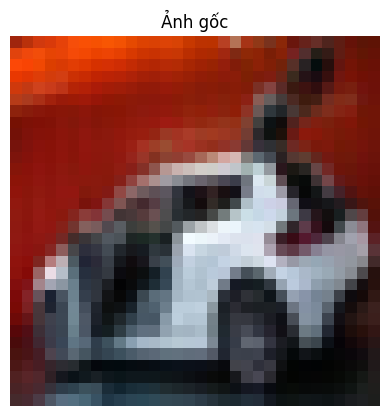

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Dự đoán: cat
Nhãn đúng: automobile


In [ ]:
# Danh sách nhãn (class names)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Chọn ảnh thứ i trong tập test
i = 6  # có thể thay bằng chỉ số khác
plt.imshow(x_test[i])
plt.axis('off')
plt.title("Ảnh gốc")
plt.show()

# Dự đoán
prediction = model.predict(x_test[i].reshape(1, 32, 32, 3))
predicted_label = class_names[prediction.argmax()]
true_label = class_names[y_test[i]]

print(f"Dự đoán: {predicted_label}")
print(f"Nhãn đúng: {true_label}")


**2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên cung cấp với các nhãn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

#Đọc tập dữ liệu MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
#Xử lý bộ dữ liệu
  #Reshape
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
  #Scale dữ liệu
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))

Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


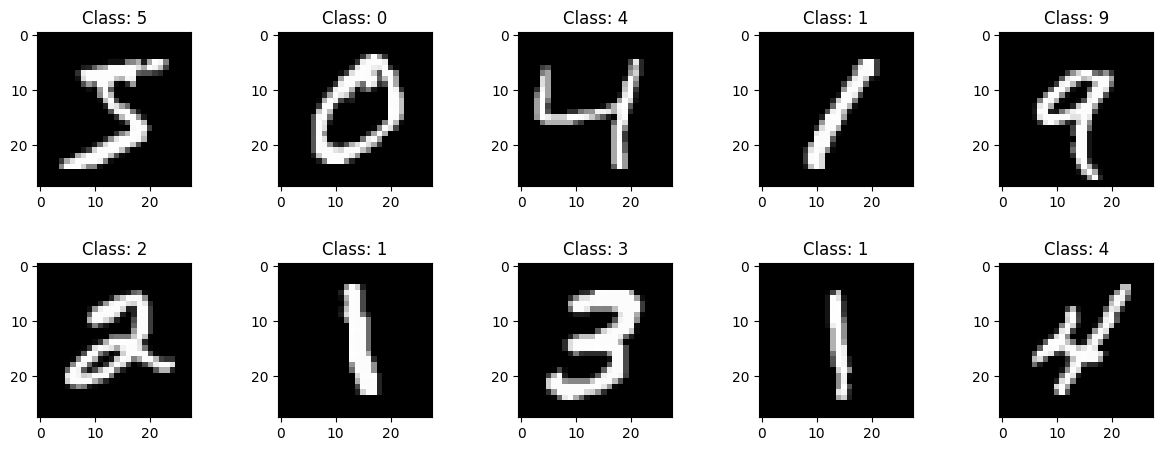

In [ ]:
#Trực quan hóa dữ liệu
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
#Xây dựng mô hình học ANN
model = Sequential()
model.add(Dense(input_dim=784, units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

  #Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Huấn luyện ANN model
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8711 - loss: 0.4712 - val_accuracy: 0.9663 - val_loss: 0.1189
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9654 - loss: 0.1178 - val_accuracy: 0.9767 - val_loss: 0.0900
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9785 - loss: 0.0709 - val_accuracy: 0.9765 - val_loss: 0.0797
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9848 - loss: 0.0480 - val_accuracy: 0.9755 - val_loss: 0.0805
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accuracy: 0.9800 - val_loss: 0.0756
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9919 - loss: 0.0263 - val_accuracy: 0.9765 - val_loss: 0.0835
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 0.9798 - val_loss: 0.0732
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9951 - loss: 0.01

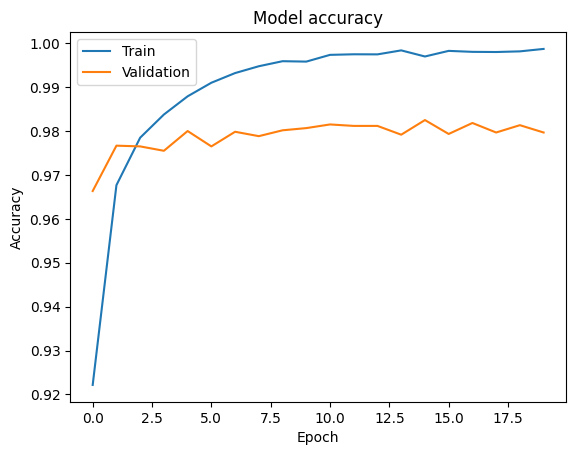

In [ ]:
#Đánh giá ANN model
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

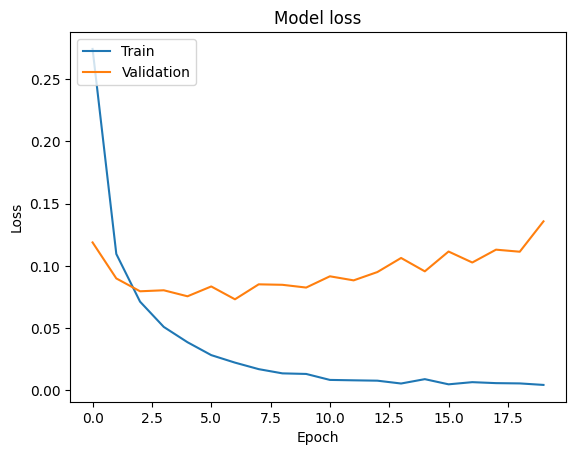

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#Dự báo ảnh mới
print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7 7
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0 0


Bài 4

Số lượng giá trị '?' trong tập train:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Số lượng giá trị '?' trong tập test:
age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64
X_train_processed shape: (32561, 105)
X_test_processed shape: (16281, 105)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,633 (37.63 KB)

 Non-trainable params: 224 (896.00 B)

None
Epoch 1/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7204 - loss: 0.5750 - val_accuracy: 0.8431 - val_loss: 0.3362
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8311 - loss: 0.3619 - val_accuracy: 0.8523 - val_loss: 0.3193
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8407 - loss: 0.3437 - val_accuracy: 0.8524 - val_loss: 0.3184
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8477 - loss: 0.3257 - val_accuracy: 0.8561 - val_loss: 0.3111
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8429 - loss: 0.3294 - val_accuracy: 0.8557 - val_loss: 0.3074
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8494 - loss: 0.3246 - val_accuracy: 0.8540 - val_loss: 0.3078
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8535 - loss: 0.3165 - val_accuracy: 0.8571 - val_loss: 0.3071
Epoch 8/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8491 - loss: 0.3195 - val_accura

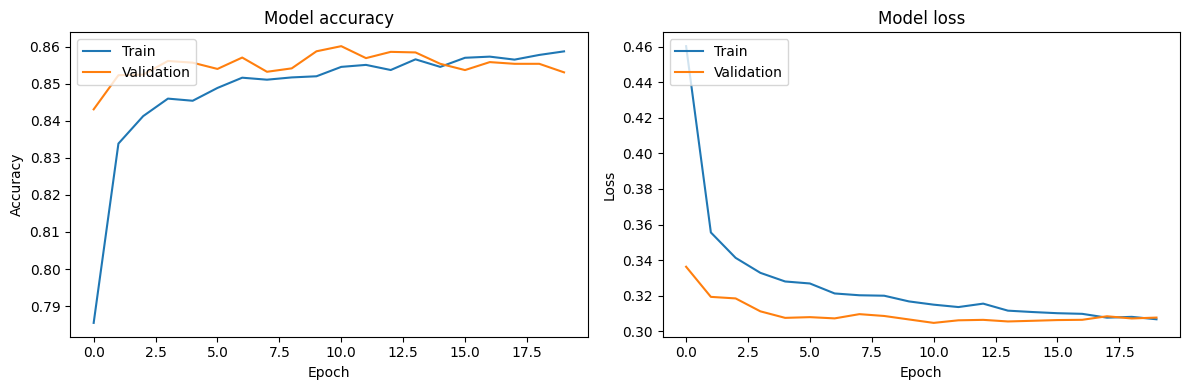


Mẫu dữ liệu:
   age  workclass  fnlwgt   education  education_num      marital_status  \
0   25    Private  226802        11th              7       Never-married   
1   38    Private   89814     HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951  Assoc-acdm             12  Married-civ-spouse   

          occupation relationship   race   sex  capital_gain  capital_loss  \
0  Machine-op-inspct    Own-child  Black  Male             0             0   
1    Farming-fishing      Husband  White  Male             0             0   
2    Protective-serv      Husband  White  Male             0             0   

   hours_per_week native_country  
0              40  United-States  
1              50  United-States  
2              40  United-States  

Dự đoán thu nhập:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Mẫu 1: <=50K
Mẫu 2: <=50K
Mẫu 3: <=50K


In [ ]:
#Viết chương trình cài đặt ANN để dự báo thu nhập một người > 50K/năm hay <= 50K/năm (nhãn cuối) theo bộ dữ liệu adult do giảng viên cung cấp

# Định nghĩa tên các cột
column_names = [
  'age', 'workclass', 'fnlwgt', 'education', 'education_num',
  'marital_status', 'occupation', 'relationship', 'race', 'sex',
  'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Đọc dữ liệu train
df_train = pd.read_csv('adult.data', header=None, names=column_names, sep=', ', engine='python')

# Đọc dữ liệu test
df_test = pd.read_csv('adult.test', header=None, names=column_names, sep=', ', engine='python', skiprows=1)  # Bỏ qua dòng đầu tiên vì có '|1x3 Cross validator'

# Loại bỏ dấu chấm trong nhãn thu nhập của tập test
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

# Kiểm tra xem có dữ liệu bị thiếu hoặc là "?"
print("Số lượng giá trị '?' trong tập train:")
print((df_train == '?').sum())
print("\nSố lượng giá trị '?' trong tập test:")
print((df_test == '?').sum())

# Thay thế các giá trị "?" bằng giá trị phổ biến nhất
for column in df_train.columns:
  if df_train[column].dtype == object:  # Chỉ xử lý các cột dạng chuỗi
    most_frequent = df_train[column].value_counts().index[0]
    if most_frequent != '?':  # Đảm bảo giá trị phổ biến nhất không phải "?"
      df_train[column] = df_train[column].replace('?', most_frequent)
      df_test[column] = df_test[column].replace('?', most_frequent)

# Xác định các đặc trưng (features) và nhãn (labels)
X_train = df_train.drop('income', axis=1)
y_train = df_train['income']
X_test = df_test.drop('income', axis=1)
y_test = df_test['income']

# Mã hóa nhãn thu nhập
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)  # <=50K là 0, >50K là 1
y_test = label_encoder.transform(y_test)

# Xác định các cột dạng số và dạng chuỗi
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=[object]).columns.tolist()

# Tạo pipeline chuyển đổi dữ liệu
preprocessor = ColumnTransformer(
  transformers=[
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
  ])

# Áp dụng tiền xử lý
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Kiểm tra kích thước của dữ liệu sau khi xử lý
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

# Xây dựng mô hình ANN
def build_model(input_dim):
  model = keras.Sequential([
    layers.Dense(64, activation='relu', input_dim=input_dim),
      layers.BatchNormalization(),
      layers.Dropout(0.3),
      layers.Dense(32, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.2),
      layers.Dense(16, activation='relu'),
      layers.BatchNormalization(),
      layers.Dense(1, activation='sigmoid')
  ])

  model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
  )
  return model

# Khởi tạo mô hình
input_dim = X_train_processed.shape[1]
model = build_model(input_dim)
print(model.summary())

# Huấn luyện mô hình
history = model.fit(
  X_train_processed, y_train,
  epochs=20,
  batch_size=64,
  validation_split=0.2,
  verbose=1
)

# Đánh giá mô hình
y_pred_prob = model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Đánh giá kết quả
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Vẽ đồ thị quá trình huấn luyện
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Hàm dự đoán cho dữ liệu mới
def predict_income(data):
  # Tiền xử lý dữ liệu mới
  data_processed = preprocessor.transform(data)
  # Dự đoán
  prediction = model.predict(data_processed)
  # Chuyển đổi kết quả dự đoán
  result = (prediction > 0.5).astype(int)
  # Trả về kết quả
  return ['<=50K' if r == 0 else '>50K' for r in result]

# Ví dụ về cách sử dụng hàm dự đoán
# Lấy 3 mẫu từ tập test
sample_data = X_test.iloc[:3]
print("\nMẫu dữ liệu:")
print(sample_data)
print("\nDự đoán thu nhập:")
predictions = predict_income(sample_data)
for i, pred in enumerate(predictions):
  print(f"Mẫu {i+1}: {pred}")

Bài 3

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Tải bộ dữ liệu Cats vs Dogs từ TFDS
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

# Chia dữ liệu huấn luyện và kiểm tra thủ công
train_data = dataset['train']
test_data = train_data.skip(int(0.8 * len(list(train_data))))  # Lấy 20% dữ liệu còn lại làm tập kiểm tra
train_data = train_data.take(int(0.8 * len(list(train_data))))  # Lấy 80% làm tập huấn luyện

# Định nghĩa hàm tiền xử lý ảnh
def preprocess(image, label):
    image = tf.image.resize(image, [128, 128])  # Resize ảnh về kích thước 128x128 thay vì 200x200 như ban đầu
    image = tf.cast(image, tf.float32) / 255.0  # Chuẩn hóa pixel về khoảng [0,1]
    return image, label

# Áp dụng tiền xử lý cho dữ liệu huấn luyện và kiểm tra
train_dataset = train_data.map(preprocess).shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)  # Dùng batch size nhỏ hơn 32
test_dataset = test_data.map(preprocess).batch(16).prefetch(tf.data.AUTOTUNE)  # Dùng batch size nhỏ hơn 32

# Xây dựng mô hình ANN với một lớp Dense
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(128, 128, 3)),  # Thay đổi kích thước ảnh vào (128x128 thay vì 200x200)
    tf.keras.layers.Dense(128, activation='relu'),  # Lớp ẩn
    tf.keras.layers.Dense(1, activation='sigmoid')  # Lớp đầu ra nhị phân
])

# Biên dịch mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Huấn luyện mô hình
history = model.fit(train_dataset, validation_data=test_dataset, epochs=5)

# Đánh giá mô hình trên dữ liệu kiểm tra
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc}")

# Kiểm tra mô hình với một batch từ test dataset
for images, labels in test_dataset.take(1):
    predictions = model.predict(images)
    for i in range(len(images)):
        true_label = 'Dog' if labels[i].numpy() == 1 else 'Cat'
        predicted_label = 'Dog' if predictions[i] > 0.5 else 'Cat'
        print(f"True label: {true_label} | Predicted: {predicted_label}")


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1164/1164 ━━━━━━━━━━━━━━━━━━━━ 140s 117ms/step - accuracy: 0.5284 - loss: 3.4487 - val_accuracy: 0.5276 - val_loss: 1.0553
Epoch 2/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.5781 - loss: 0.9022 - val_accuracy: 0.5732 - val_loss: 0.6743
Epoch 3/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 135s 113ms/step - accuracy: 0.5979 - loss: 0.6676 - val_accuracy: 0.6213 - val_loss: 0.6535
Epoch 4/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 128s 109ms/step - accuracy: 0.5875 - loss: 0.6672 - val_accuracy: 0.6056 - val_loss: 0.6668
Epoch 5/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 134s 114ms/step - accuracy: 0.6100 - loss: 0.6571 - val_accuracy: 0.6140 - val_loss: 0.6662
291/291 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.6035 - loss: 0.6692
Test accuracy: 0.6140124797821045
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
True label: Dog | Predicted: Dog
True label: Cat | Predicted: Cat
True label: Cat | Predicted: Dog
True label: Cat | Predicted: Dog
True label: Cat | Predicted: Cat
True label: Cat | Predicted: D